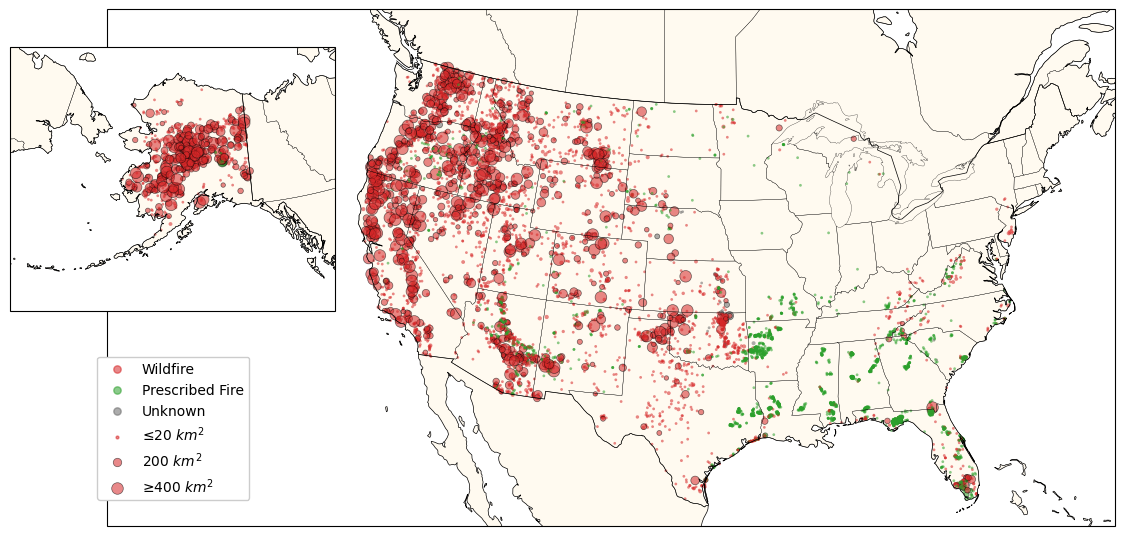

In [3]:
''' Fig 1: Make CONUS + Alaska fire map '''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df = pd.read_csv("../../../inputData/fireslist2012-2024_withtype_no_fline_hawaii.csv")

df["lon_mid"] = (pd.to_numeric(df["lon0"], errors="coerce") + pd.to_numeric(df["lon1"], errors="coerce")) / 2.0
df["lat_mid"] = (pd.to_numeric(df["lat0"], errors="coerce") + pd.to_numeric(df["lat1"], errors="coerce")) / 2.0

lon = df["lon_mid"].to_numpy(copy=True)
lon = np.where(lon > 180, lon - 360, lon)
df["lon_mid"] = lon

valid = df["lon_mid"].between(-180, 180) & df["lat_mid"].between(-90, 90)
plot_df = df.loc[valid].copy()

raw_sizes = pd.to_numeric(plot_df["BurnBndAc"]) if "BurnBndAc" in plot_df.columns else None
if raw_sizes is None or not np.issubdtype(raw_sizes.dtype, np.number):
    sizes = np.full(len(plot_df), 20.0)  # constant if area missing
else:
    s = raw_sizes.clip(lower=0)
    lo, hi = s.quantile(0.02), s.quantile(0.98)
    s = s.clip(lower=lo, upper=hi)
    sizes = (s / (hi if hi > 0 else 1.0)) * 70.0
    sizes = np.maximum(sizes, 4) # min visible size
    sizes = np.where(plot_df["Incid_Type"] == "Prescribed Fir", 4, sizes)

#add colors for fire type
color_map = {
    "Wildfire": "tab:red",
    "Prescribed Fire": "tab:green",
    "Unknown": "dimgray"
}
colors = plot_df["Incid_Type"].map(color_map).fillna("dimgray").to_numpy()
#add lines only for large fires
linewidths = np.where(sizes > 10, 0.5, 0)

#PLOT CONUS
fig = plt.figure(figsize=(13, 6.8))
#ax = plt.axes(projection=ccrs.epsg(9311))
#ax.set_extent([-135, -75, 23, 53], crs=ccrs.PlateCarree())
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-96))
ax.set_extent([-135, -72, 24, 49], crs=ccrs.PlateCarree())

akax = fig.add_axes([0.05, 0.4, 0.25, 0.45], projection=ccrs.LambertConformal(central_longitude=-150))
akax.set_extent([-180, -130, 50, 72], crs=ccrs.PlateCarree())

# Basemap
ax.add_feature(cfeature.LAND, facecolor="floralwhite")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
try:
    ax.add_feature(cfeature.STATES, linewidth=0.2)
except Exception:
    pass

#Alaska Basemap
akax.add_feature(cfeature.LAND, facecolor="floralwhite")
akax.add_feature(cfeature.COASTLINE, linewidth=0.5)
akax.add_feature(cfeature.BORDERS, linewidth=0.5)
try:
    akax.add_feature(cfeature.STATES, linewidth=0.2)
except Exception:
    pass

#Plot fires
ax.scatter(
    plot_df["lon_mid"], plot_df["lat_mid"],
    s=sizes, alpha=0.55, color=colors,
    linewidths=linewidths, edgecolors="black",
    transform=ccrs.PlateCarree()
)
akax.scatter(
    plot_df["lon_mid"], plot_df["lat_mid"],
    s=sizes, alpha=0.55, color=colors,
    linewidths=linewidths, edgecolors="black",
    transform=ccrs.PlateCarree()
)

#make legend
wildfire = plt.scatter([], [], color='tab:red', label='Wildfire', s=28, alpha=0.55)
prescribed = plt.scatter([], [], color='tab:green', label='Prescribed Fire', s=28, alpha=0.55)
unknown = plt.scatter([], [], color='dimgray', label='Unknown', s=28, alpha=0.55)
small = plt.scatter([], [], color='tab:red', label=r'≤20 $km^{2}$', s=4, alpha=0.55)
medium = plt.scatter([], [], color='tab:red', label=r'200 $km^{2}$', s=37, alpha=0.55, linewidth=0.5, edgecolor="black")
large = plt.scatter([], [], color='tab:red', label=r'≥400 $km^{2}$', s=70, alpha=0.55, linewidth=0.5, edgecolor="black")

ax.legend(
    handles=[wildfire, prescribed, unknown, small, medium, large],
    loc=(-0.01,0.05),
    frameon=True,
    facecolor='white',
    framealpha=1
)

#plt.savefig("US_fire_map.png", dpi=300)
plt.show()

Total cube folders: 6994
Valid ignition elevations: 6994
Cube folders with no matching Event_ID: 0
Cube folders with missing dem.tif: 0
Cube folders with zero-byte dem.tif: 0
Sample/read errors: 0
Nodata / invalid DEM values: 0


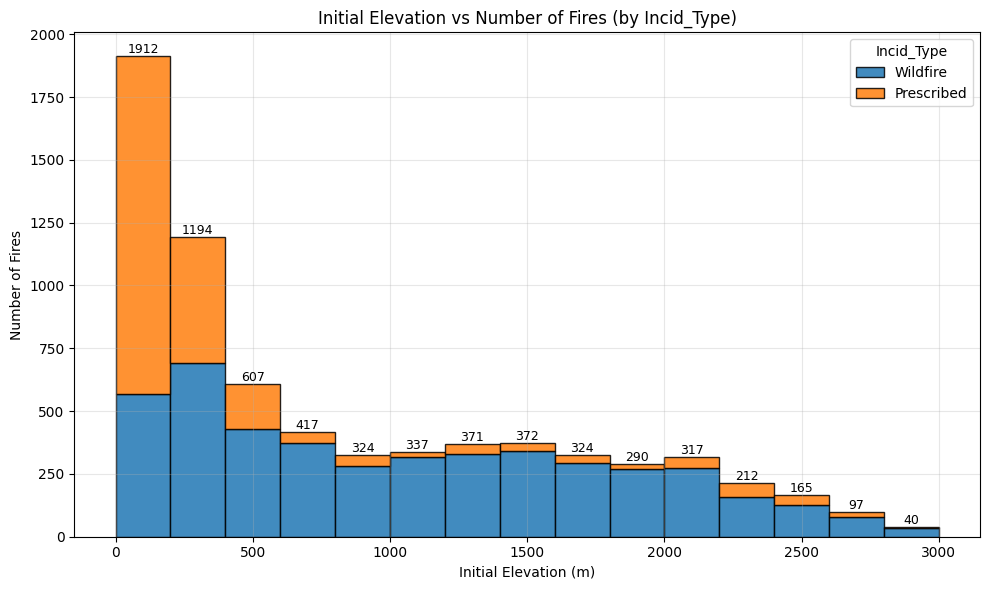


Elevation statistics (m):
Min     = 0.00
Max     = 3469.50
Mean    = 837.72
Median  = 513.00
                Event_ID Incid_Type  elevation
0  CA3878212060420140913   Wildfire     1134.0
1  CA3858612053820210815   Wildfire     1021.0
2  NV3993011458820220709   Wildfire     2286.0
3  NV4067411551020180930   Wildfire     2207.0
4  OK3480209891420220313   Wildfire      453.0


In [4]:
''' Fig 2d: Retrieve fire ignition elevations '''

%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.warp import transform
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_initial_elevation_from_cubes(
    firelist_path="../../../inputData/fireslist2012-2024_withtype_no_fline_hawaii.csv",
    cubes_root="../../../output/cubes",
    fire_id_col="Event_ID",
    lon_col="lon0",
    lat_col="lat0",
    incid_type_col="Incid_Type",
    dem_relpath="landfire",
    elev_bins=None,                 # e.g. np.arange(0, 3200, 200)
    type_order=("Wildfire", "Prescribed"),
    type_colors=None,
    make_plot=True
):
    if type_colors is None:
        type_colors = {"Wildfire": "#1f77b4", "Prescribed": "#ff7f0e"}
    if elev_bins is None:
        elev_bins = np.arange(0, 3200, 200)

    cubes_root = Path(cubes_root)
    df = pd.read_csv(firelist_path)

    for col in [fire_id_col, lon_col, lat_col, incid_type_col]:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in firelist")

    # Normalize Incid_Type to exactly two categories -- lump "unknown" type into wildfires
    df[incid_type_col] = (
        df[incid_type_col].astype(str).str.strip()
        .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire", "Unknown": "Wildfire"})
    )
    df = df[df[incid_type_col].isin(list(type_order))].copy()

    df[fire_id_col] = df[fire_id_col].astype(str)
    suffix_len = int(df[fire_id_col].str.len().mode().iloc[0])

    # Map Event_ID -> (lon, lat, Incid_Type)
    id_to_info = {
        str(row[fire_id_col]): (float(row[lon_col]), float(row[lat_col]), str(row[incid_type_col]))
        for _, row in df.iterrows()
    }

    rows = []
    missing_dem = 0
    zero_size_dem = 0
    cube_without_match = 0
    sample_errors = 0
    nodata_count = 0

    total_cube_folders = 0

    for d in cubes_root.iterdir():
        if not d.is_dir():
            continue
        total_cube_folders += 1

        name = d.name
        if len(name) < suffix_len:
            continue

        event_id = name[-suffix_len:]
        if event_id not in id_to_info:
            print(event_id)
            cube_without_match += 1
            continue

        lon, lat, incid_type = id_to_info[event_id]

        farea_path = d / "fire_spread/fperim.tif"
        if farea_path.is_file():
            try:
                with rasterio.open(farea_path) as src:
                    first_feds_slice = src.read(1)
                    first_feds_slice = np.repeat(np.repeat(first_feds_slice, 10, axis=1), 10, axis=0)
                    rs, cs = np.where(first_feds_slice)
                    row_start, row_stop = rs.min(), rs.max() + 1
                    col_start, col_stop = cs.min(), cs.max() + 1
                    width = col_stop - col_start
                    height = row_stop - row_start
                    window = Window(col_start, row_start, width, height)
                    mask = first_feds_slice[row_start:row_stop, col_start:col_stop].astype(bool)
            except Exception as e:
                print(f"Warning for cube {name}: {e}")
                sample_errors += 1
                continue
        else:
            continue
        
        dem_dir = d / dem_relpath

        if dem_dir.is_dir():
            dem_path = next(dem_dir.glob("*elev*.tif"), None)
        else:
            missing_dem += 1
            continue
        
        if dem_path.stat().st_size == 0:
            zero_size_dem += 1
            continue

        try:
            with rasterio.open(dem_path) as src:
                src_crs = src.crs
    
                vals = src.read(1, window=window)
                vals_sampled = vals[(mask) & (~np.isnan(vals))]
                if src.nodata is not None:
                    vals_sampled = vals_sampled[vals_sampled != src.nodata]
    
                if vals_sampled.size > 0:
                    val = np.nanmedian(vals_sampled)
                    if np.isnan(val):
                        nodata_count += 1
                        continue
                else:
                    nodata_count += 1
                    continue
    
                rows.append({
                    fire_id_col: event_id,
                    incid_type_col: incid_type,
                    "elevation": float(val)
                })

        except Exception as e:
            print(f"Warning for cube {name}: {e}")
            sample_errors += 1
            continue

    elev_df = pd.DataFrame(rows)

    print(f"Total cube folders: {total_cube_folders}")
    print(f"Valid ignition elevations: {len(elev_df)}")
    print(f"Cube folders with no matching Event_ID: {cube_without_match}")
    print(f"Cube folders with missing dem.tif: {missing_dem}")
    print(f"Cube folders with zero-byte dem.tif: {zero_size_dem}")
    print(f"Sample/read errors: {sample_errors}")
    print(f"Nodata / invalid DEM values: {nodata_count}")

    if elev_df.empty:
        print("No valid ignition elevations collected.")
        return elev_df

    if make_plot:
        w = elev_df.loc[elev_df[incid_type_col] == type_order[0], "elevation"].to_numpy()
        p = elev_df.loc[elev_df[incid_type_col] == type_order[1], "elevation"].to_numpy()

        # Explicit histograms (same idea as veg_counts_by_type)
        w_counts, bin_edges = np.histogram(w, bins=elev_bins)
        p_counts, _         = np.histogram(p, bins=elev_bins)

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        totals = w_counts + p_counts
        ymax = totals.max() if len(totals) else 0

        plt.figure(figsize=(10, 6))

        # Stacked bars
        plt.bar(
            bin_centers,
            w_counts,
            width=np.diff(bin_edges),
            edgecolor="black",
            alpha=0.85,
            color=type_colors[type_order[0]],
            label=type_order[0],
            align="center",
        )
        plt.bar(
            bin_centers,
            p_counts,
            width=np.diff(bin_edges),
            bottom=w_counts,
            edgecolor="black",
            alpha=0.85,
            color=type_colors[type_order[1]],
            label=type_order[1],
            align="center",
        )

        for x, total in zip(bin_centers, totals):
            if total > 0:
                plt.text(
                    x,
                    total,
                    str(int(total)),
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        plt.title("Initial Elevation vs Number of Fires (by Incid_Type)")
        plt.xlabel("Initial Elevation (m)")
        plt.ylabel("Number of Fires")
        plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
        plt.grid(True, alpha=0.3)
        plt.legend(title=incid_type_col)
        plt.tight_layout()
        plt.show()

    # Stats (overall)
    vals = elev_df["elevation"].to_numpy()
    print("\nElevation statistics (m):")
    print(f"Min     = {np.nanmin(vals):.2f}")
    print(f"Max     = {np.nanmax(vals):.2f}")
    print(f"Mean    = {np.nanmean(vals):.2f}")
    print(f"Median  = {np.nanmedian(vals):.2f}")

    return elev_df


elev_df = plot_initial_elevation_from_cubes(
    cubes_root="/dfs10/jranders_lab2/projects/FireCube/output/cubes",
)

print(elev_df.head())
elev_df.to_csv('elev.csv')

Total cube folders: 6994
Valid ignition vegetation samples: 6990
Cube folders with no matching Event_ID: 0
Cube folders with missing EVT raster: 0
Cube folders with zero-byte EVT raster: 0
Sample/read errors: 0
Nodata / invalid EVT values: 0
Unknown EVT codes (not in legend): 0


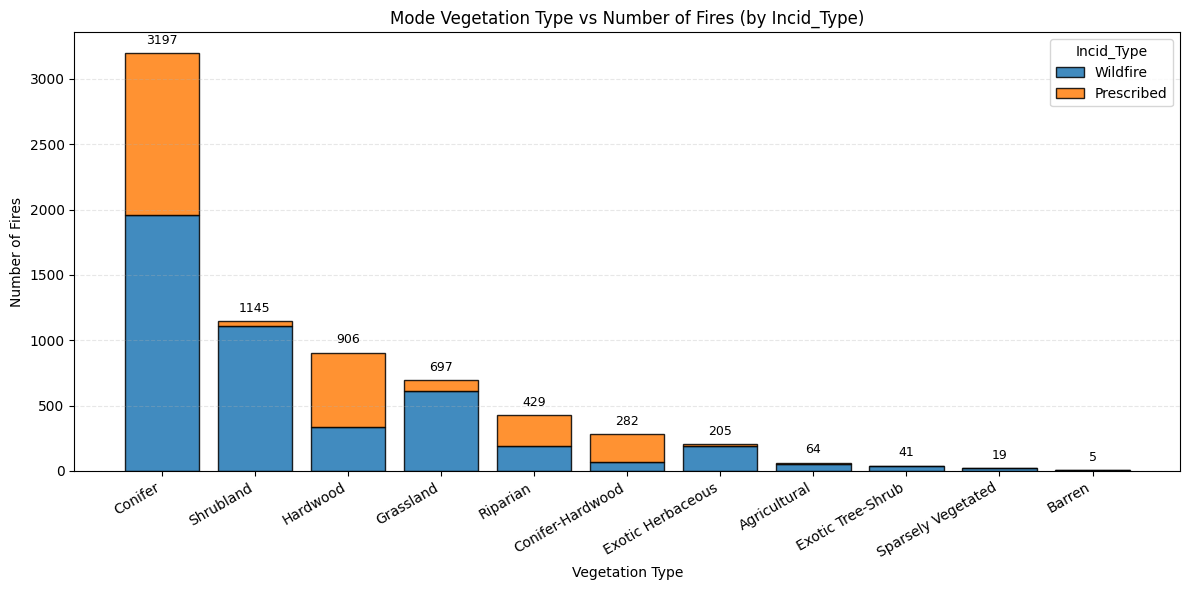

In [6]:
''' Fig 2e: Retrieve mode vegetation types '''

from pathlib import Path
import pandas as pd
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.warp import transform
import matplotlib.pyplot as plt

def plot_ignition_veg_from_cubes(
    firelist_path="../../../inputData/fireslist2012-2024_withtype.csv",
    cubes_root="../../../output/cubes",
    lf_legend_path_old="../../../inputData/LF2014_EVT.csv",
    lf_legend_path_new="../../../inputData/LF2024_EVT.csv",
    fire_id_col="Event_ID",
    lon_col="lon0",
    lat_col="lat0",
    evt_code_col="VALUE",      # column in LF2024_EVT that matches EVT codes
    evt_phys_col="EVT_PHYS",   # vegetation type column
    incid_type_col="Incid_Type",
    type_order=("Wildfire", "Prescribed"),
    type_colors=None
):
    if type_colors is None:
        type_colors = {
            "Wildfire": "#1f77b4",
            "Prescribed": "#ff7f0e",
        }

    cubes_root = Path(cubes_root)

    fires = pd.read_csv(firelist_path)

    for col in [fire_id_col, lon_col, lat_col, incid_type_col]:
        if col not in fires.columns:
            raise ValueError(f"Column '{col}' not found in firelist")

    # Normalize Incid_Type so we only have Wildfire / Prescribed
    fires[incid_type_col] = (
        fires[incid_type_col]
        .astype(str)
        .str.strip()
        .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire", "Unknown": "Wildfire"})
    ) 
    fires = fires[fires[incid_type_col].isin(list(type_order))].copy()

    fires[fire_id_col] = fires[fire_id_col].astype(str)
    id_lengths = fires[fire_id_col].str.len()
    suffix_len = int(id_lengths.mode().iloc[0])

    # Map Event_ID -> (lon, lat, Incid_Type)
    id_to_info = {
        str(row[fire_id_col]): (float(row[lon_col]), float(row[lat_col]), str(row[incid_type_col]))
        for _, row in fires.iterrows()
    }

    lf_old = pd.read_csv(lf_legend_path_old)
    if evt_code_col not in lf_old.columns or evt_phys_col not in lf_old.columns:
        raise ValueError(
            f"Expected columns '{evt_code_col}' and '{evt_phys_col}' in {lf_legend_path_old}. "
            f"Available columns: {lf_old.columns.tolist()}"
        )

    lf_new = pd.read_csv(lf_legend_path_new)
    if evt_code_col not in lf_new.columns or evt_phys_col not in lf_new.columns:
        raise ValueError(
            f"Expected columns '{evt_code_col}' and '{evt_phys_col}' in {lf_legend_path_new}. "
            f"Available columns: {lf_new.columns.tolist()}"
        )

    evtcode_old_to_phys = dict(zip(lf_old[evt_code_col].astype(int), lf_old[evt_phys_col].astype(str)))
    evtcode_new_to_phys = dict(zip(lf_new[evt_code_col].astype(int), lf_new[evt_phys_col].astype(str)))
    evtcode_to_phys = {'old' : evtcode_old_to_phys, 'new' : evtcode_new_to_phys}

    rows = []

    missing_evt = 0
    zero_size_evt = 0
    cube_without_match = 0
    sample_errors = 0
    nodata_count = 0
    unknown_evt_code = 0

    nodata_cubes = []
    unknown_evt_cubes = []

    total_cube_folders = 0

    for d in cubes_root.iterdir():
        if not d.is_dir():
            continue
        total_cube_folders += 1

        name = d.name
        if len(name) < suffix_len:
            continue

        suffix = name[-suffix_len:]  # Event_ID used in CSV
        year = int(suffix[-8:-4])

        if suffix not in id_to_info:
            cube_without_match += 1
            continue

        lon, lat, incid_type = id_to_info[suffix]

        farea_path = d / "fire_spread/fperim.tif"
        if farea_path.is_file():
            try:
                with rasterio.open(farea_path) as src:
                    last_feds_slice = src.read(src.count)
                    last_feds_slice = np.repeat(np.repeat(last_feds_slice, 10, axis=1), 10, axis=0)
                    rs, cs = np.where(last_feds_slice)
                    row_start, row_stop = rs.min(), rs.max() + 1
                    col_start, col_stop = cs.min(), cs.max() + 1
                    width = col_stop - col_start
                    height = row_stop - row_start
                    window = Window(col_start, row_start, width, height)
                    mask = last_feds_slice[row_start:row_stop, col_start:col_stop].astype(bool)

                    if not mask.any():
                        mask = mask.fill(True)
            except Exception as e:
                print(f"Warning for cube {name}: {e}")
                sample_errors += 1
                continue
        else:
            continue

        evt_relpath = "landfire"
        evt_dir = d / evt_relpath

        if evt_dir.is_dir():
            evt_path = next(evt_dir.glob("*evt*.tif"), None)
        else:
            missing_evt += 1
            continue

        try:
            with rasterio.open(evt_path) as src:
                src_crs = src.crs
                
                all_evt = src.read(1, window=window)
                sampled_evt = all_evt[mask]
                total_pixels = sampled_evt.size
                threshold = total_pixels * 0.10
    
                #retrieve evt code values and sort them by their count
                vals, counts = np.unique(sampled_evt, return_counts=True)
                sorted_indices = np.argsort(counts)[::-1]
                sorted_vals = vals[sorted_indices]
                sorted_counts = counts[sorted_indices]

                if year < 2017:
                    evt_version = 'old'
                else:
                    evt_version = 'new'

                for val, count in zip(sorted_vals, sorted_counts):
                    if count < threshold:
                        break 
                
                    if np.isnan(val) or (src.nodata is not None and val == src.nodata):
                        continue
                
                    if val in evtcode_to_phys[evt_version]:
                        veg_type = evtcode_to_phys[evt_version][val]
                
                        if any(keyword in veg_type for keyword in ["Water", "Road", "Developed", "NoData", "Nodata"]):
                            continue
                
                        rows.append({
                            fire_id_col: suffix,
                            incid_type_col: incid_type,
                            "veg_type": veg_type
                        })
                        break

        except Exception as e:
            print(f"Warning for cube {name}: {e}")
            sample_errors += 1
            continue
    
    veg_df = pd.DataFrame(rows)

    print(f"Total cube folders: {total_cube_folders}")
    print(f"Valid ignition vegetation samples: {len(veg_df)}")
    print(f"Cube folders with no matching Event_ID: {cube_without_match}")
    print(f"Cube folders with missing EVT raster: {missing_evt}")
    print(f"Cube folders with zero-byte EVT raster: {zero_size_evt}")
    print(f"Sample/read errors: {sample_errors}")
    print(f"Nodata / invalid EVT values: {nodata_count}")
    print(f"Unknown EVT codes (not in legend): {unknown_evt_code}")

    if nodata_cubes:
        print("\nCubes with NoData EVT at ignition point (first 20):")
        for c in nodata_cubes[:20]:
            print("  ", c)
        if len(nodata_cubes) > 20:
            print(f"  ... and {len(nodata_cubes) - 20} more")

    if unknown_evt_cubes:
        print("\nCubes with EVT codes not found in LF2024_EVT legend (first 20):")
        for c, code in unknown_evt_cubes[:20]:
            print(f"  {c}: code={code}")
        if len(unknown_evt_cubes) > 20:
            print(f"  ... and {len(unknown_evt_cubes) - 20} more")

    if veg_df.empty:
        print("No valid ignition vegetation types collected.")
        return veg_df, pd.DataFrame()

    veg_counts_by_type = (
        veg_df.groupby(["veg_type", incid_type_col])
              .size()
              .unstack(incid_type_col)
              .fillna(0)
    )

    # Ensure both types exist as columns + consistent order
    for t in type_order:
        if t not in veg_counts_by_type.columns:
            veg_counts_by_type[t] = 0
    veg_counts_by_type = veg_counts_by_type[list(type_order)]

    # Sort by total count descending (so plot matches your earlier style)
    veg_counts_by_type = veg_counts_by_type.loc[
        veg_counts_by_type.sum(axis=1).sort_values(ascending=False).index
    ]

    # Plot stacked bar chart (2 colors)
    plt.figure(figsize=(12, 6))
    x = np.arange(len(veg_counts_by_type.index))
    bottom = np.zeros(len(x))

    for t in type_order:
        vals = veg_counts_by_type[t].to_numpy()
        plt.bar(
            veg_counts_by_type.index,
            vals,
            bottom=bottom,
            edgecolor="black",
            alpha=0.85,
            label=t,
            color=type_colors.get(t, None),
        )
        bottom += vals

    totals = veg_counts_by_type.sum(axis=1).to_numpy()
    ymax = totals.max() if len(totals) else 0
    for i, total in enumerate(totals):
        if total > 0:
            plt.text(i, total + ymax * 0.015, str(int(total)), ha="center", va="bottom", fontsize=9)

    plt.title("Mode Vegetation Type vs Number of Fires (by Incid_Type)")
    plt.xlabel("Vegetation Type")
    plt.ylabel("Number of Fires")
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis="y", alpha=0.3, linestyle="--")
    plt.legend(title=incid_type_col)
    plt.tight_layout()
    plt.show()

    return veg_df, veg_counts_by_type


veg_df, veg_counts_by_type = plot_ignition_veg_from_cubes(
    cubes_root="/dfs10/jranders_lab2/projects/FireCube/output/cubes"
)
veg_df.to_csv('veg.csv')

/tmp/ipykernel_41829/3166006744.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["size_bin", "Incid_Type"]).size()
/tmp/ipykernel_41829/3166006744.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dur_df.groupby(["dur_bin", "Incid_Type"]).size()


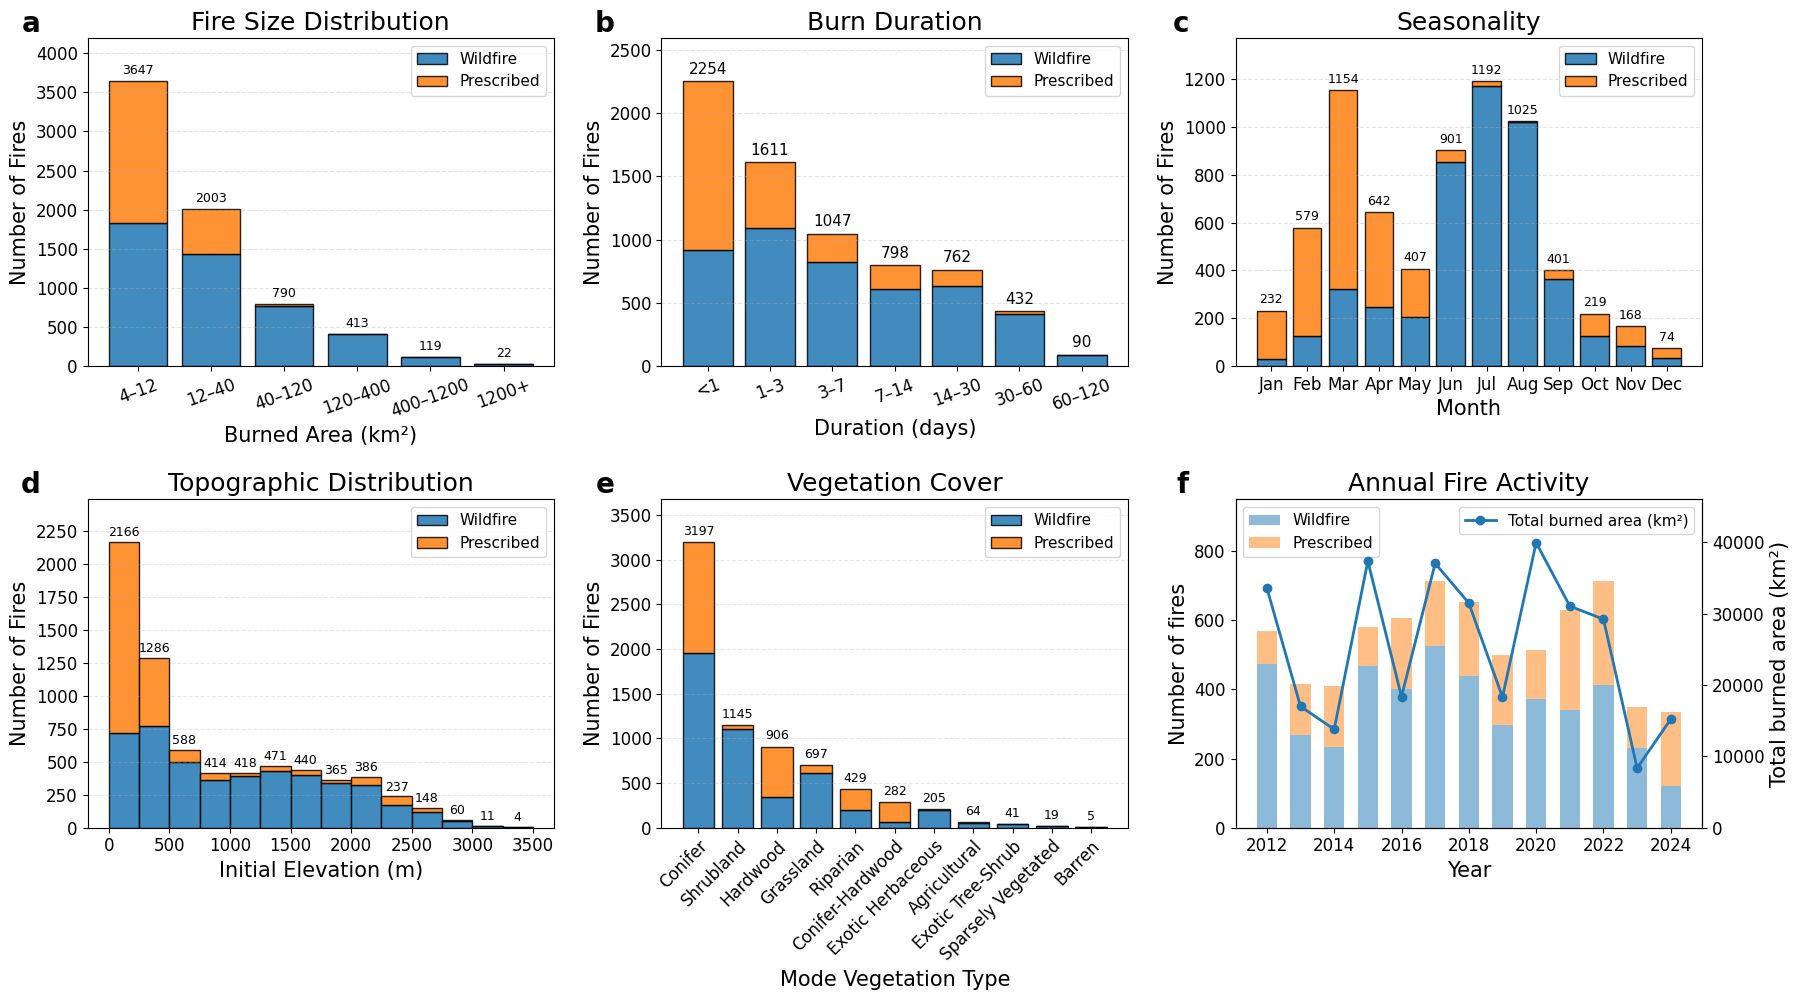

In [10]:
''' Fig 2: Plot all 6 panels '''

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 22
})

# 0) Load + normalize firelist
firelist_path = "../../../inputData/fireslist2012-2024_withtype_no_fline_hawaii.csv"
firelist = pd.read_csv(firelist_path)

if "Incid_Type" not in firelist.columns:
    raise KeyError("Column 'Incid_Type' not found in firelist. Make sure you're using the *_withtype.csv file.")

firelist["Incid_Type"] = (
    firelist["Incid_Type"].astype(str).str.strip()
    .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire", "Unknown": "Wildfire"})
)

TYPE_ORDER  = ["Wildfire", "Prescribed"]
TYPE_COLORS = {"Wildfire": "#1f77b4", "Prescribed": "#ff7f0e"}

firelist = firelist[firelist["Incid_Type"].isin(TYPE_ORDER)].copy()

elev_df = pd.read_csv('elev.csv')
veg_df  = pd.read_csv('veg.csv')

# Copy
elev_df = elev_df.copy()
veg_df  = veg_df.copy()

if "Incid_Type" not in elev_df.columns:
    elev_df = elev_df.merge(firelist[["Event_ID", "Incid_Type"]], on="Event_ID", how="inner")

if "Incid_Type" not in veg_df.columns:
    veg_df = veg_df.merge(firelist[["Event_ID", "Incid_Type"]], on="Event_ID", how="inner")

# Normalize types inside these dfs too
elev_df["Incid_Type"] = (
    elev_df["Incid_Type"].astype(str).str.strip()
    .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire"})
)
veg_df["Incid_Type"] = (
    veg_df["Incid_Type"].astype(str).str.strip()
    .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire"})
)

elev_df = elev_df[elev_df["Incid_Type"].isin(TYPE_ORDER)].copy()
veg_df  = veg_df[veg_df["Incid_Type"].isin(TYPE_ORDER)].copy()

# 1) Make combined panel
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, hspace=0.05, wspace=0.05)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

# 1) Burned Area histogram
TARGET_YEAR = None
data = firelist.copy()
if TARGET_YEAR is not None and "Year" in data.columns:
    data = data[data["Year"] == TARGET_YEAR]

sizes_km2 = pd.to_numeric(data["BurnBndAc"], errors="coerce") * 0.00404686
data = data.assign(size_km2=sizes_km2).replace([np.inf, -np.inf], np.nan).dropna(subset=["size_km2"])
data = data[data["size_km2"] >= 4]

bins   = [4, 12, 40, 120, 400, 1200, np.inf]
labels = ["4–12", "12–40", "40–120", "120–400", "400–1200", "1200+"]

data["size_bin"] = pd.cut(data["size_km2"], bins=bins, labels=labels, right=False, include_lowest=True)

counts_by_type = (
    data.groupby(["size_bin", "Incid_Type"]).size()
        .unstack("Incid_Type").reindex(labels).fillna(0)
)
for t in TYPE_ORDER:
    if t not in counts_by_type.columns:
        counts_by_type[t] = 0
counts_by_type = counts_by_type[TYPE_ORDER]

bottom = np.zeros(len(labels))
for t in TYPE_ORDER:
    vals = counts_by_type[t].to_numpy()
    ax1.bar(labels, vals, bottom=bottom, edgecolor="black", alpha=0.85,
            label=t, color=TYPE_COLORS[t])
    bottom += vals

totals = counts_by_type.sum(axis=1).to_numpy()
ymax = totals.max() if len(totals) else 0
ax1.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
for i, total in enumerate(totals):
    ax1.text(i, total + ymax * 0.015, str(int(total)), ha="center", va="bottom", fontsize=9)

ax1.set_title("Fire Size Distribution")
ax1.set_xlabel("Burned Area (km²)")
ax1.set_ylabel("Number of Fires")
ax1.set_xticks(ax1.get_xticks())
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20)
ax1.grid(axis="y", linestyle="--", alpha=0.35)
ax1.legend()

# 2) Duration histogram
tst_dt = pd.to_datetime(firelist["tst"], errors="coerce")
ted_dt = pd.to_datetime(firelist["ted"], errors="coerce")
tst_dt = tst_dt.dt.floor("D") + pd.Timedelta(hours=1, minutes=30)

dur_days = (ted_dt - tst_dt).dt.total_seconds() / 86400.0
dur_df = firelist.copy()
dur_df["dur_days"] = dur_days
dur_df = dur_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["dur_days"])
dur_df = dur_df[dur_df["dur_days"] >= 0]

bins   = [0, 1, 3, 7, 14, 30, 60, 120]
labels = ["<1", "1–3", "3–7", "7–14", "14–30", "30–60", "60–120"]

dur_df["dur_bin"] = pd.cut(dur_df["dur_days"], bins=bins, labels=labels, right=False, include_lowest=True)

counts_by_type = (
    dur_df.groupby(["dur_bin", "Incid_Type"]).size()
          .unstack("Incid_Type").reindex(labels).fillna(0)
)
for t in TYPE_ORDER:
    if t not in counts_by_type.columns:
        counts_by_type[t] = 0
counts_by_type = counts_by_type[TYPE_ORDER]

bottom = np.zeros(len(labels))
for t in TYPE_ORDER:
    vals = counts_by_type[t].to_numpy()
    ax2.bar(labels, vals, bottom=bottom, edgecolor="black", alpha=0.85,
            label=t, color=TYPE_COLORS[t])
    bottom += vals

totals = counts_by_type.sum(axis=1).to_numpy()
ymax = totals.max() if len(totals) else 0
ax2.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
for i, total in enumerate(totals):
    ax2.text(i, total + ymax * 0.015, str(int(total)), ha="center", va="bottom", fontsize=11)

ax2.set_title("Burn Duration")
ax2.set_xlabel("Duration (days)")
ax2.set_ylabel("Number of Fires")
ax2.set_xticks(ax2.get_xticks())
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20)
ax2.grid(axis="y", linestyle="--", alpha=0.35)
ax2.legend()

# 3) Fires per month
tst_dt2 = pd.to_datetime(firelist["tst"], errors="coerce")
month_df = firelist.copy()
month_df["month"] = tst_dt2.dt.month
month_df = month_df.dropna(subset=["month"])
month_df["month"] = month_df["month"].astype(int)

counts_by_type = (
    month_df.groupby(["month", "Incid_Type"]).size()
            .unstack("Incid_Type").reindex(range(1, 13), fill_value=0)
)
for t in TYPE_ORDER:
    if t not in counts_by_type.columns:
        counts_by_type[t] = 0
counts_by_type = counts_by_type[TYPE_ORDER]

month_labels = [pd.to_datetime(str(m), format="%m").strftime("%b") for m in range(1, 13)]

bottom = np.zeros(12)
for t in TYPE_ORDER:
    vals = counts_by_type[t].to_numpy()
    ax3.bar(month_labels, vals, bottom=bottom, edgecolor="black", alpha=0.85,
            label=t, color=TYPE_COLORS[t])
    bottom += vals

totals = counts_by_type.sum(axis=1).to_numpy()
ymax = totals.max() if len(totals) else 0
ax3.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
for i, total in enumerate(totals):
    ax3.text(i, total + ymax * 0.015, str(int(total)), ha="center", va="bottom", fontsize=9)

ax3.set_title("Seasonality")
ax3.set_xlabel("Month")
ax3.set_ylabel("Number of Fires")
ax3.grid(axis="y", linestyle="--", alpha=0.35)
ax3.legend()

# 4) Initial elevation histogram
if "elev_df" not in globals() or elev_df is None or len(elev_df) == 0:
    raise RuntimeError("elev_df is missing/empty. Run plot_initial_elevation_from_cubes(...) first.")

elev_plot_df = elev_df.copy()

elev_plot_df["Incid_Type"] = (
    elev_plot_df["Incid_Type"].astype(str).str.strip()
    .replace({"Prescribed Fire": "Prescribed", "Wildfire": "Wildfire"})
)

# keep only your 2 types
elev_plot_df = elev_plot_df[elev_plot_df["Incid_Type"].isin(TYPE_ORDER)].copy()

# numeric elevation
elev_plot_df["elevation"] = pd.to_numeric(elev_plot_df["elevation"], errors="coerce")
elev_plot_df = elev_plot_df.dropna(subset=["elevation"])

custom_bins = np.arange(0, 3501, 250)

# split by type
w = elev_plot_df.loc[elev_plot_df["Incid_Type"] == TYPE_ORDER[0], "elevation"].to_numpy()
p = elev_plot_df.loc[elev_plot_df["Incid_Type"] == TYPE_ORDER[1], "elevation"].to_numpy()

# explicit histograms
w_counts, bin_edges = np.histogram(w, bins=custom_bins)
p_counts, _         = np.histogram(p, bins=custom_bins)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths  = np.diff(bin_edges)

totals = w_counts + p_counts
ymax = totals.max() if len(totals) else 0

# clear axis in case it had old plot
ax4.cla()

# stacked bars
ax4.bar(
    bin_centers,
    w_counts,
    width=bin_widths,
    edgecolor="black",
    alpha=0.85,
    color=TYPE_COLORS[TYPE_ORDER[0]],
    label=TYPE_ORDER[0],
    align="center",
)
ax4.bar(
    bin_centers,
    p_counts,
    width=bin_widths,
    bottom=w_counts,
    edgecolor="black",
    alpha=0.85,
    color=TYPE_COLORS[TYPE_ORDER[1]],
    label=TYPE_ORDER[1],
    align="center",
)

# total labels on top of each stacked bar (bring closer by reducing offset factor)
label_offset = ymax * 0.01
for x, total in zip(bin_centers, totals):
    if total > 0:
        ax4.text(
            x,
            total + label_offset,
            str(int(total)),
            ha="center",
            va="bottom",
            fontsize=9,
        )

# cosmetics
ax4.set_title("Topographic Distribution")
ax4.set_xlabel("Initial Elevation (m)")
ax4.set_ylabel("Number of Fires")
ax4.grid(axis="y", linestyle="--", alpha=0.3)
ax4.yaxis.set_major_locator(MaxNLocator(integer=True))
ax4.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
ax4.legend()

# 5) Vegetation
veg_plot_df = veg_df.copy()

veg_counts_by_type = (
    veg_plot_df.groupby(["veg_type", "Incid_Type"]).size()
               .unstack("Incid_Type").fillna(0)
)
for t in TYPE_ORDER:
    if t not in veg_counts_by_type.columns:
        veg_counts_by_type[t] = 0
veg_counts_by_type = veg_counts_by_type[TYPE_ORDER]
veg_counts_by_type = veg_counts_by_type.loc[
    veg_counts_by_type.sum(axis=1).sort_values(ascending=False).index
]

bottom = np.zeros(len(veg_counts_by_type.index))
for t in TYPE_ORDER:
    vals = veg_counts_by_type[t].to_numpy()
    ax5.bar(
        veg_counts_by_type.index, vals,
        bottom=bottom, edgecolor="black", alpha=0.85,
        label=t, color=TYPE_COLORS[t]
    )
    bottom += vals

totals = veg_counts_by_type.sum(axis=1).to_numpy()
ymax = totals.max() if len(totals) else 0
ax5.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)
for i, total in enumerate(totals):
    ax5.text(i, total + ymax * 0.015, str(int(total)), ha="center", va="bottom", fontsize=9)

ax5.set_title("Vegetation Cover")
ax5.set_xlabel("Mode Vegetation Type")
ax5.set_ylabel("Number of Fires")
ax5.set_xticks(ax5.get_xticks())
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax5.grid(axis="y", alpha=0.3, linestyle="--")
ax5.legend()

# 6) Number of fires per year
area_col = "BurnBndAc"
year_col = "Year"
id_col = "Event_ID"

year_type_counts = (
    firelist.groupby([year_col, "Incid_Type"])[id_col].nunique()
            .unstack("Incid_Type").fillna(0).sort_index()
)
for t in TYPE_ORDER:
    if t not in year_type_counts.columns:
        year_type_counts[t] = 0
year_type_counts = year_type_counts[TYPE_ORDER]

year_total_area_km2 = (
    firelist.groupby(year_col)[area_col].sum().sort_index().astype(float) * 0.00404686
)

years = year_type_counts.index.to_numpy()

bottom = np.zeros(len(years))
for t in TYPE_ORDER:
    vals = year_type_counts[t].to_numpy()
    ax6.bar(years, vals, bottom=bottom, alpha=0.5, width=0.6,
            label=t, color=TYPE_COLORS[t])
    bottom += vals

ax6.set_ylim(0, 950)
ax6.set_xlabel("Year")
ax6.set_ylabel("Number of fires")
ax6.set_title("Annual Fire Activity")

ax6b = ax6.twinx()
ax6b.plot(year_total_area_km2.index.to_numpy(), year_total_area_km2.to_numpy(),
          marker="o", linewidth=2, label="Total burned area (km²)")
ax6b.set_ylabel("Total burned area (km²)")
ax6b.set_ylim(0, 46000)

ax6.legend(loc="upper left")
ax6b.legend(loc="upper right")

all_axes = [ax1, ax2, ax3, ax4, ax5, ax6]
panel_labels = ['a', 'b', 'c', 'd', 'e', 'f']

for ax, label in zip(all_axes, panel_labels):
    # transform=ax.transAxes means (0,0) is bottom-left and (1,1) is top-right of the subplot
    ax.text(-0.1, 1.0, label, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='bottom', ha='right')

#plt.savefig('fires_summary.png', bbox_inches='tight', dpi=300)
plt.show()

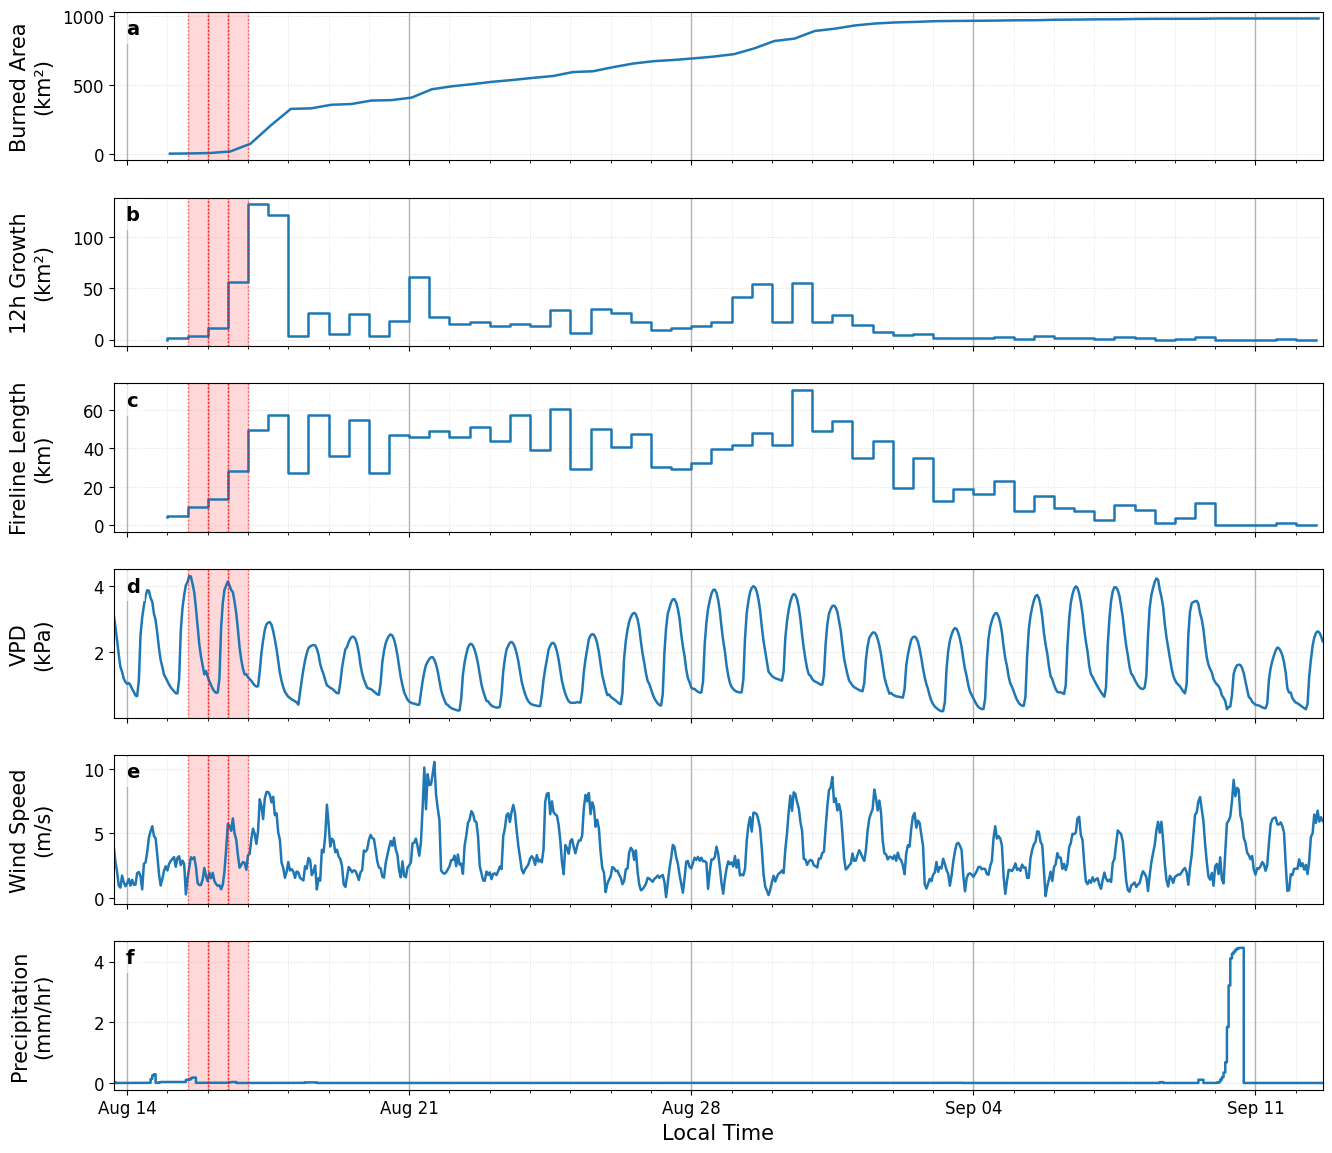

In [6]:
''' Fig 4: Plot Caldor time series '''

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import geopandas as gpd

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 22
})

def _span_days(lo, hi) -> float:
    dt = pd.to_datetime(hi) - pd.to_datetime(lo)
    return dt.total_seconds() / 86400.0

def _best_loc_and_fmt(lo, hi):
    """Choose tick locator/formatter based on span in days."""
    d = _span_days(lo, hi)
    if d <= 10:
        loc = mdates.DayLocator(interval=1)
        fmt = mdates.DateFormatter("%b %d")
    elif d <= 35:
        loc = mdates.WeekdayLocator(byweekday=mdates.MO, interval=1)
        fmt = mdates.DateFormatter("%b %d")
    elif d <= 120:
        loc = mdates.MonthLocator(interval=1)
        fmt = mdates.DateFormatter("%b %Y")
    else:
        loc = mdates.MonthLocator(interval=2)
        fmt = mdates.DateFormatter("%b %Y")
    return loc, fmt

def _grid_freq(lo, hi) -> str:
    d = _span_days(lo, hi)
    if d <= 10:   return "D"
    if d <= 35:   return "W-MON"
    if d <= 120:  return "MS"
    return "2MS"

def _iter_ticks(start, end, freq):
    s = pd.to_datetime(start)
    e = pd.to_datetime(end)
    rng = pd.date_range(start=s.floor("D"), end=e.ceil("D"), freq=freq)
    return rng[(rng >= s) & (rng <= e)]

def _maybe_wider_fig(lo, hi, base=(12, 4)):
    """Widen figure for longer fires, like in your example."""
    d = _span_days(lo, hi)
    width = max(base[0], min(22, 12 + 0.12 * d))
    return (width, base[1])

def _make_axis_converters(local_series: pd.Series, utc_series: pd.Series):
    """
    Build mapping functions:
      local2utc(x_local_num) -> x_utc_num
      utc2local(x_utc_num)   -> x_local_num
    where x_*_num are matplotlib date numbers.
    """
    xL = mdates.date2num(pd.to_datetime(local_series))
    xU = mdates.date2num(pd.to_datetime(utc_series))

    # Sort by Local and drop duplicate Local values
    order = np.argsort(xL)
    xL, xU = xL[order], xU[order]
    maskL = np.concatenate([[True], np.diff(xL) > 0])
    xL, xU = xL[maskL], xU[maskL]

    def local2utc(x):
        return np.interp(x, xL, xU, left=xU[0], right=xU[-1])

    # Sort by UTC and drop duplicate UTC values
    orderU = np.argsort(xU)
    xU2, xL2 = xU[orderU], xL[orderU]
    maskU = np.concatenate([[True], np.diff(xU2) > 0])
    xU2, xL2 = xU2[maskU], xL2[maskU]

    def utc2local(x):
        return np.interp(x, xU2, xL2, left=xL2[0], right=xL2[-1])

    return local2utc, utc2local

csv_path = "sample_caldor_table.csv"
gpkg_path = "../../../inputData/Full_FEDS/2021/CA3858612053820210815.gpkg"

# Load & sort
df = (
    pd.read_csv(csv_path, sep="\t", parse_dates=["UTC", "Local"])
      .sort_values("Local")
      .reset_index(drop=True)
)

perim = gpd.read_file(gpkg_path, layer="perimeter")
perim["t"] = pd.to_datetime(perim["t"])

if "flinelen" not in perim.columns:
    raise ValueError(f"'flinelen' column not found in perimeter layer. Available: {perim.columns.tolist()}")

fl = perim[["t", "flinelen"]].dropna(subset=["flinelen"]).copy()
fl["Local"] = fl["t"]  # make it explicit

# Full window
LOCAL_START = df["Local"].iloc[0]
LOCAL_END   = df["Local"].iloc[-1]
UTC_START   = df["UTC"].iloc[0]
UTC_END     = df["UTC"].iloc[-1]

cutoff_utc = pd.Timestamp("2021-09-13 00:00:00")

# Build converters once from full series
local2utc, utc2local = _make_axis_converters(df["Local"], df["UTC"])

merged = pd.merge(
    df[["UTC", "Local"]],
    fl[["Local", "flinelen"]],
    on="Local",
    how="left"
)

d = merged.dropna(subset=["flinelen"]).copy()
if d.empty:
    raise ValueError("No overlapping timestamps between CSV and GPKG for flinelen.")

# Helper: clip a column from df by UTC cutoff
def clip_from_df(colname, cutoff):
    if colname not in df.columns:
        raise ValueError(f"{colname} not in df.columns")
    mask = (df["UTC"] <= cutoff) & df[colname].notna()
    t_local = df.loc[mask, "Local"]
    t_utc   = df.loc[mask, "UTC"]
    values  = df.loc[mask, colname].astype(float)
    if values.empty:
        raise ValueError(f"No valid {colname} values before {cutoff}.")
    return t_local, t_utc, values

# Burned area (cumulative)
t_local_area, t_utc_area, area = clip_from_df("fperim_area_km2", cutoff_utc)

area_df = (
    pd.DataFrame({"Local": t_local_area, "UTC": t_utc_area, "cum_km2": area})
    .sort_values("UTC")
    .reset_index(drop=True)
)

area_df["bin_12h"] = area_df["Local"].dt.floor("12h")

# Burned area per 12h = max(cum) - min(cum) within that 12h bin
area_12h = (
    area_df.groupby("bin_12h", as_index=False)
    .agg(cum_km2_end=("cum_km2", "last"))
)

area_12h["burned_km2_12h"] = area_12h["cum_km2_end"].diff().fillna(0).clip(lower=0)

# Center points in each 12h window for plotting
area_12h["x_local"] = area_12h["bin_12h"]

# VPD
t_local_vpd, t_utc_vpd, vpd = clip_from_df("vpd", cutoff_utc)

# Wind speed
t_local_ws, t_utc_ws, ws = clip_from_df("ws_mean", cutoff_utc)

# Precipitation
t_local_tp, t_utc_tp, tp = clip_from_df("tp", cutoff_utc)

# Fireline length from merged table d
if "flinelen" not in d.columns:
    raise ValueError("'flinelen' not found in merged table d.")
mask_fl = (d["UTC"] <= cutoff_utc) & d["flinelen"].notna()
t_local_fl = d.loc[mask_fl, "Local"]
t_utc_fl   = d.loc[mask_fl, "UTC"]
fl         = d.loc[mask_fl, "flinelen"].astype(float)
if fl.empty:
    raise ValueError("No flinelen values before cutoff.")

LOCAL_START_SUB = min(
    t_local_area.min(), area_12h["x_local"].min(), t_local_fl.min(),
    t_local_vpd.min(), t_local_ws.min(), t_local_tp.min()
)
LOCAL_END_SUB = max(
    t_local_area.max(), area_12h["x_local"].max(), t_local_fl.max(),
    t_local_vpd.max(), t_local_ws.max(), t_local_tp.max()
)

UTC_START_SUB = min(
    t_utc_area.min(), t_utc_fl.min(),
    t_utc_vpd.min(), t_utc_ws.min(), t_utc_tp.min()
)
UTC_END_SUB = max(
    t_utc_area.max(), t_utc_fl.max(),
    t_utc_vpd.max(), t_utc_ws.max(), t_utc_tp.max()
)

width, _ = _maybe_wider_fig(LOCAL_START_SUB, LOCAL_END_SUB)
fig, axes = plt.subplots(
    nrows=6, ncols=1,                  
    figsize=(width, 14),              
    sharex=True,
    gridspec_kw={"hspace": 0.25}
)

ax_area, ax_12h, ax_fl, ax_vpd, ax_ws, ax_tp = axes
LPAD = 15

# 1) Burned area (cumulative)
ax_area.plot(t_local_area, area, linewidth=1.8)
ax_area.set_ylabel("Burned Area\n(km²)", labelpad=LPAD)
ax_area.grid(alpha=0.4, linestyle=":")

# 2) 12hr burned area
ax_12h.step(area_12h["x_local"], area_12h["burned_km2_12h"], where='pre', linewidth=1.8)
ax_12h.set_ylabel("12h Growth\n(km²)", labelpad=LPAD)
ax_12h.grid(alpha=0.4, linestyle=":")

# 3) Fireline length
ax_fl.step(t_local_fl, fl, where="pre", linewidth=1.8)
ax_fl.set_ylabel("Fireline Length\n(km)", labelpad=LPAD)
ax_fl.grid(alpha=0.4, linestyle=":")

# 4) VPD
ax_vpd.plot(t_local_vpd, vpd, linewidth=1.8)
ax_vpd.set_ylabel("VPD\n(kPa)", labelpad=LPAD)
ax_vpd.grid(alpha=0.4, linestyle=":")

# 5) Wind speed
ax_ws.plot(t_local_ws, ws, linewidth=1.8)
ax_ws.set_ylabel("Wind Speed\n(m/s)", labelpad=LPAD)
ax_ws.grid(alpha=0.4, linestyle=":")

# 6) Precipitation
ax_tp.step(t_local_tp, tp, where="post", linewidth=1.8)
ax_tp.set_ylabel("Precipitation\n(mm/hr)", labelpad=LPAD)
ax_tp.grid(alpha=0.4, linestyle=":")

ax_tp.set_xlim(LOCAL_START_SUB, LOCAL_END_SUB)
first_midnight = LOCAL_START_SUB.normalize() + pd.Timedelta(days=1)
tick_dates = pd.date_range(start=first_midnight, end=LOCAL_END_SUB, freq='7D')
ax_tp.xaxis.set_major_locator(mticker.FixedLocator(mdates.date2num(tick_dates)))
ax_tp.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
ax_tp.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_tp.set_xlabel("Local Time")

for ax in axes:
    ax.grid(True, which='major', axis='x', linestyle='-', linewidth=1.0, alpha=0.6, color="grey")
    ax.grid(True, which='minor', axis='x', linestyle=':', linewidth=0.5, alpha=0.3, color="grey")

plt.setp(ax_tp.get_xticklabels(), rotation=0, ha='center')

for ax in axes:
    ax.yaxis.set_label_coords(-0.05, 0.5)

shading_starts = [
    pd.Timestamp("2021-08-15 12:00:00"),
    pd.Timestamp("2021-08-16 00:00:00"),
    pd.Timestamp("2021-08-16 12:00:00")
]

for start in shading_starts:
    end = start + pd.Timedelta(hours=12)
    
    for ax in axes:
        # Add the light red shaded area
        ax.axvspan(start, end, color='red', alpha=0.15, zorder=0)
        
        # Add the "bookend" dotted lines for precision
        ax.axvline(start, color='red', linestyle=':', linewidth=1, alpha=0.6)
        ax.axvline(end, color='red', linestyle=':', linewidth=1, alpha=0.6)

for ax, label in zip(axes, ['a', 'b', 'c', 'd', 'e', 'f']):
    ax.text(0.01, 0.95, f"{label}", transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.savefig('caldor_timeseries.png', bbox_inches='tight', dpi=300)
plt.show()


In [4]:
print(df[["Local", "tp"]].head())
print(df["Local"].diff().value_counts().head())
print(df["Local"].diff().median())

                Local        tp
0 2021-08-13 16:00:00  0.029657
1 2021-08-13 16:30:00       NaN
2 2021-08-13 17:00:00  0.000139
3 2021-08-13 17:30:00       NaN
4 2021-08-13 18:00:00  0.000155
Local
0 days 00:30:00    2302
Name: count, dtype: int64
0 days 00:30:00
